Đang load dữ liệu từ file...
Bắt đầu huấn luyện mô hình...
Hoàn tất! Độ chính xác trên tập Test: 55.54%


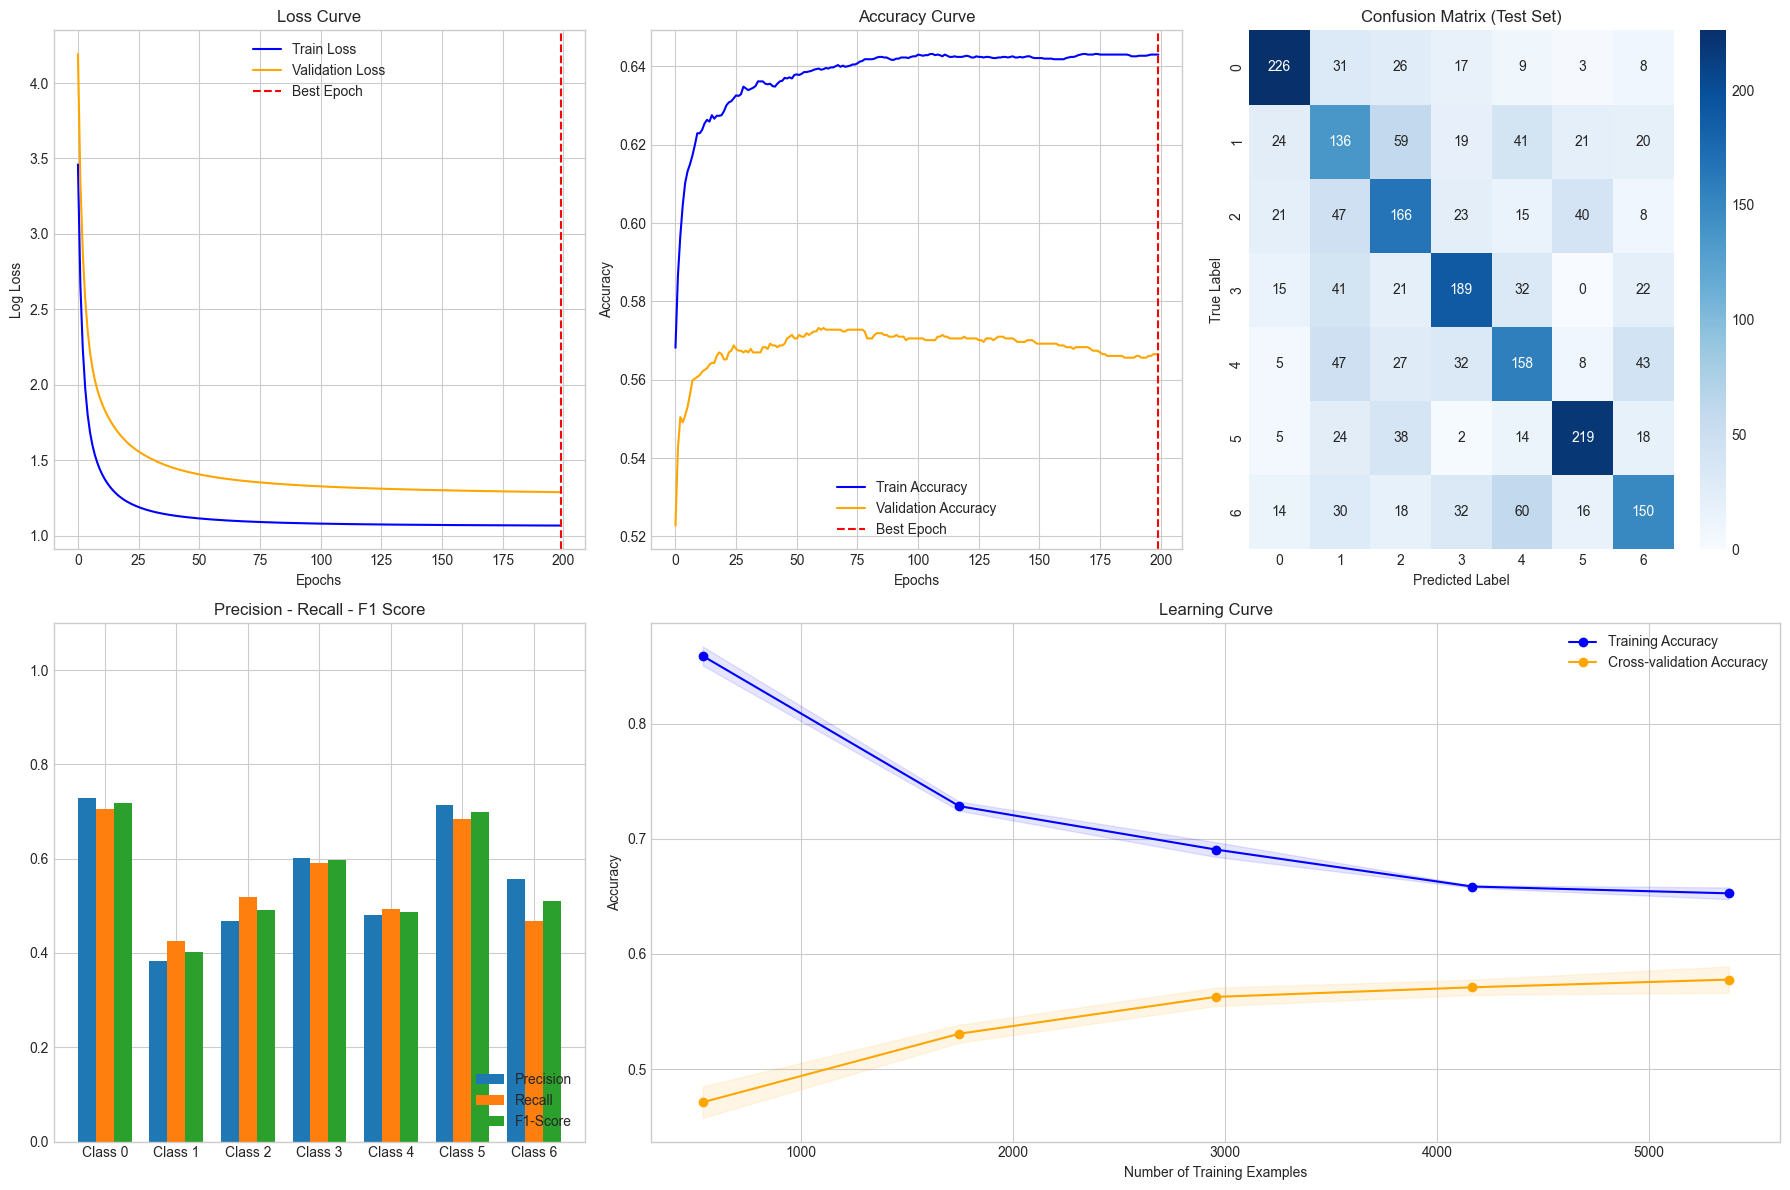


--- BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       320
           1       0.38      0.42      0.40       320
           2       0.47      0.52      0.49       320
           3       0.60      0.59      0.60       320
           4       0.48      0.49      0.49       320
           5       0.71      0.68      0.70       320
           6       0.56      0.47      0.51       320

    accuracy                           0.56      2240
   macro avg       0.56      0.56      0.56      2240
weighted avg       0.56      0.56      0.56      2240


[Lưu trữ] Đã lưu toàn bộ Model và Scaler vào: C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel\softmax_model.pkl
[Lưu trữ] Đã lưu ma trận W (shape: (7, 263)) vào: C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel\W_weights.npy
[Lưu trữ] Đã lưu vector bias b (shape: (7,)) vào: C:\Users\binhm

In [9]:
# Cài đặt thư viện nếu chạy lần đầu: !pip install numpy scikit-learn matplotlib seaborn
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
import joblib


# Hiển thị biểu đồ ngay trong Jupyter Notebook
%matplotlib inline

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU (MÔ PHỎNG NẾU KHÔNG CÓ FILE)
# ==========================================
features_file = r"C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel\X_features.npy"
labels_file = r"C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel\y_labels.npy"
# Nếu bạn chưa có file từ bước trích xuất, code sẽ tạo dữ liệu giả lập (Dummy Data) để biểu đồ vẫn hiển thị
if not os.path.exists(features_file):
    print("Không tìm thấy file đặc trưng thật, đang tạo dữ liệu giả lập (1000 mẫu, 3 lớp, 263 chiều)...")
    np.random.seed(42)
    # Giả lập 1000 ảnh, mỗi ảnh có vector đặc trưng 263 chiều, chia làm 3 lớp (0, 1, 2)
    X = np.random.randn(1000, 263) 
    y = np.random.choice([0, 1, 2], size=1000)
else:
    print("Đang load dữ liệu từ file...")
    X = np.load(features_file)
    y = np.load(labels_file)

# Chia dữ liệu: Train (60%), Validation (20%), Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. HUẤN LUYỆN VÀ GHI LẠI LỊCH SỬ (HISTORY)
# ==========================================
model = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01, random_state=42, warm_start=True)

classes = np.unique(y_train)

# Khởi tạo các list lưu trữ lịch sử
train_losses, val_losses = [], []
train_accs, val_accs = [], []

max_epochs = 200
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_weights = None
best_bias = None
best_epoch = 0

print("Bắt đầu huấn luyện mô hình...")
for epoch in range(max_epochs):
    # Cập nhật trọng số với partial_fit
    model.partial_fit(X_train_scaled, y_train, classes=classes)
    
    # Tính Loss (Log Loss)
    train_probs = model.predict_proba(X_train_scaled)
    val_probs = model.predict_proba(X_val_scaled)
    loss_train = log_loss(y_train, train_probs)
    loss_val = log_loss(y_val, val_probs)
    
    # Tính Accuracy
    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_val = accuracy_score(y_val, model.predict(X_val_scaled))
    
    # Ghi nhận lịch sử
    train_losses.append(loss_train)
    val_losses.append(loss_val)
    train_accs.append(acc_train)
    val_accs.append(acc_val)
    
    # Cơ chế Dừng sớm (Early Stopping)
    if loss_val < best_val_loss:
        best_val_loss = loss_val
        epochs_no_improve = 0
        best_epoch = epoch
        best_weights = model.coef_.copy()
        best_bias = model.intercept_.copy()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"-> Early stopping kích hoạt tại epoch {epoch}. Khôi phục trọng số tốt nhất ở epoch {best_epoch}.")
            break

# Cập nhật mô hình với trọng số tốt nhất
model.coef_ = best_weights
model.intercept_ = best_bias

# Đánh giá trên tập Test độc lập
y_test_pred = model.predict(X_test_scaled)
print(f"Hoàn tất! Độ chính xác trên tập Test: {accuracy_score(y_test, y_test_pred) * 100:.2f}%")

# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))

# --- Biểu đồ 1: Loss Curve ---
ax1 = plt.subplot(2, 3, 1)
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Validation Loss', color='orange')
ax1.axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Log Loss')
ax1.legend()

# --- Biểu đồ 2: Accuracy Curve ---
ax2 = plt.subplot(2, 3, 2)
ax2.plot(train_accs, label='Train Accuracy', color='blue')
ax2.plot(val_accs, label='Validation Accuracy', color='orange')
ax2.axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# --- Biểu đồ 3: Confusion Matrix ---
ax3 = plt.subplot(2, 3, 3)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title('Confusion Matrix (Test Set)')
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')

# --- Biểu đồ 4: Precision, Recall, F1-Score Bar Chart ---
ax4 = plt.subplot(2, 3, 4)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average=None)
x_labels = [f"Class {c}" for c in classes]
x = np.arange(len(x_labels))
width = 0.25

ax4.bar(x - width, precision, width, label='Precision', color='#1f77b4')
ax4.bar(x, recall, width, label='Recall', color='#ff7f0e')
ax4.bar(x + width, f1, width, label='F1-Score', color='#2ca02c')

ax4.set_title('Precision - Recall - F1 Score')
ax4.set_xticks(x)
ax4.set_xticklabels(x_labels)
ax4.set_ylim(0, 1.1)
ax4.legend(loc='lower right')

# --- Biểu đồ 5: Learning Curve ---
ax5 = plt.subplot(2, 3, (5, 6)) # Gộp cột 5 và 6 để kéo dài biểu đồ
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

ax5.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
ax5.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax5.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation Accuracy')
ax5.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')

ax5.set_title('Learning Curve')
ax5.set_xlabel('Number of Training Examples')
ax5.set_ylabel('Accuracy')
ax5.legend()

# Căn chỉnh layout và hiển thị
plt.tight_layout()
plt.show()

# Hiển thị luôn báo cáo chi tiết dạng Text
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_test_pred))



# ==========================================
# 4. LƯU MÔ HÌNH VÀ TRỌNG SỐ RA FILE
# ==========================================
# Khai báo đường dẫn lưu file (bạn có thể đổi tên thư mục)
model_file = r"C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel\softmax_model.pkl"
weights_file = r"C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel\W_weights.npy"
bias_file = r"C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel\b_bias.npy"

# 1. Lưu toàn bộ Model và Scaler (Cách chuyên nghiệp, tiện dùng nhất)
# joblib nén và lưu object của Python rất hiệu quả
joblib.dump({'model': model, 'scaler': scaler}, model_file)
print(f"\n[Lưu trữ] Đã lưu toàn bộ Model và Scaler vào: {model_file}")

# 2. Lưu riêng ma trận W và bias b (Dành cho việc bạn muốn code dự đoán bằng công thức Toán học thuần túy)
np.save(weights_file, model.coef_)
np.save(bias_file, model.intercept_)
print(f"[Lưu trữ] Đã lưu ma trận W (shape: {model.coef_.shape}) vào: {weights_file}")
print(f"[Lưu trữ] Đã lưu vector bias b (shape: {model.intercept_.shape}) vào: {bias_file}")